<a href="https://colab.research.google.com/github/Thrakrien/ann-ifes-studies/blob/main/bike_sharing_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import zipfile
import urllib.request
from pathlib import Path
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers
from matplotlib import pyplot as plt


A base usada foi a Bike Sharing Dataset, composta por registros horários de aluguel de bicicletas entre 2011 e 2012. Cada linha representa uma hora e contém informações de calendário, clima e demanda, como hora do dia, dia da semana, temperatura, umidade, velocidade do vento e cnt, que é a quantidade total de bicicletas alugadas.

In [10]:
url = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"
zip_path = Path("bike_sharing.zip")
extract_dir = Path("bike_sharing")

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

df_hour = pd.read_csv(extract_dir / "hour.csv")

df = df_hour.copy()
df["dteday"] = pd.to_datetime(df["dteday"])

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df.shape

(17379, 17)

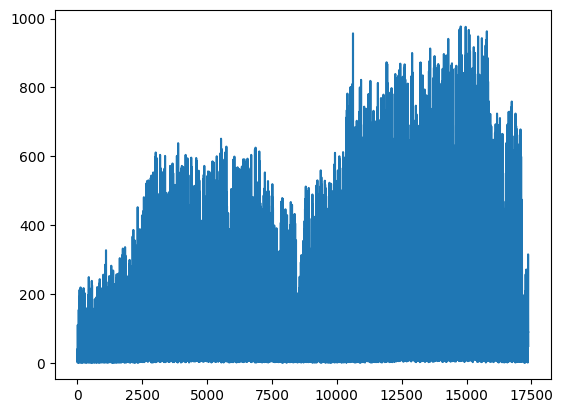

In [11]:
plt.plot(range(len(df['cnt'])), df['cnt'])
plt.show()

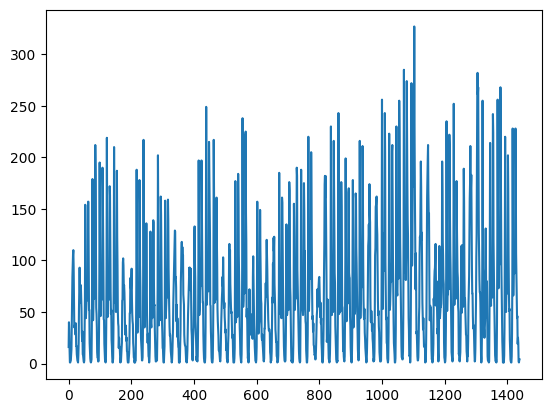

In [13]:
ten_days = 6*24*10
plt.plot(range(ten_days), df['cnt'][:ten_days])
plt.show()

In [45]:
num_train_samples = int(0.5 * len(df))
num_val_samples = int(0.25 * len(df))
num_test_samples = len(df) - num_train_samples - num_val_samples
print('num_train_samples:', num_train_samples)
print('num_val_samples:', num_val_samples)
print('num_test_samples:', num_test_samples)

num_train_samples: 8689
num_val_samples: 4344
num_test_samples: 4346


In [26]:
raw_data = df.copy()

In [28]:
int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
    sampling_rate=1,
    shuffle=False
)
print(f"Int Sequence: {int_sequence}")
for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))
    print()

Int Sequence: [0 1 2 3 4 5 6 7 8 9]
[0, 1, 2] 3
[1, 2, 3] 4

[2, 3, 4] 5
[3, 4, 5] 6

[4, 5, 6] 7



In [37]:
features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "cnt"
]

In [38]:
raw_data = df[features].to_numpy(dtype="float32")
target_data = df["cnt"].to_numpy(dtype="float32")

In [39]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=df['cnt'][delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples
)
val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=df['cnt'][delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples+num_val_samples
)
test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=df['cnt'][delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples+num_val_samples
)


In [40]:
for samples, targets in train_dataset:
    print(f"samples shape: {samples.shape}")
    print(f"targets shape: {targets.shape}")
    break

samples shape: (256, 120, 13)
targets shape: (256,)


### baseline

In [44]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [48]:
target_index = features.index("cnt")

In [51]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0

    for samples, targets in dataset:
        samples = tf.cast(samples, tf.float32)
        targets = tf.cast(targets, tf.float32)

        preds = samples[:, -1, target_index] * std[target_index] + mean[target_index]
        targets = targets * std[target_index] + mean[target_index]

        total_abs_err += tf.reduce_sum(tf.abs(preds - targets)).numpy()
        samples_seen += samples.shape[0]

    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 89.57
Test MAE: 100.91


### densely connected

In [52]:
from tensorflow import keras

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('bike_sharing_dense.keras', save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)
model = keras.models.load_model('bike_sharing_dense.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 12262.2207 - mae: 81.2540 - val_loss: 16923.5215 - val_mae: 98.4222
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 8596.1328 - mae: 66.7881 - val_loss: 14548.8574 - val_mae: 87.6989
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 7740.7305 - mae: 62.8793 - val_loss: 13923.4141 - val_mae: 81.6504
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 7404.2461 - mae: 61.1046 - val_loss: 12279.6143 - val_mae: 79.4030
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 7139.5103 - mae: 59.8234 - val_loss: 12030.9111 - val_mae: 80.3125
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 6920.7793 - mae: 58.6442 - val_loss: 12244.3604 - val_mae: 80.8421
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 6639.1382 - mae: 57.0141 - val_loss: 19112.1758 - val_mae: 112.3615
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 6746.6157 - mae: 57.6261 - val_loss: 11859.4141 - val_mae

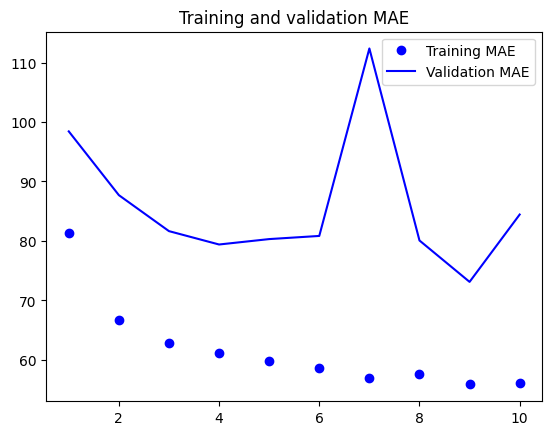

In [53]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

### 1D convolutional model

In [54]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation='relu')(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation='relu')(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation='relu')(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('bike_sharing_conv.keras', save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)
model = keras.models.load_model('bike_sharing_conv.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 19797.5215 - mae: 108.6700 - val_loss: 40027.8828 - val_mae: 162.5303
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 16910.5703 - mae: 103.3491 - val_loss: 38558.2422 - val_mae: 155.0491
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 16485.6973 - mae: 101.6787 - val_loss: 38118.6562 - val_mae: 153.2990
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 16346.2490 - mae: 100.9905 - val_loss: 39600.3984 - val_mae: 153.7372
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 16087.8301 - mae: 99.8947 - val_loss: 42198.0977 - val_mae: 156.2884
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 15960.3643 - mae: 99.3658 - val_loss: 37406.3945 - val_mae: 156.3642
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 15892.2520 - mae: 99.0497 - val_loss: 36886.3711 - val_mae: 151.0553
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 15758.9629 - mae: 98.7132 - val_loss: 3

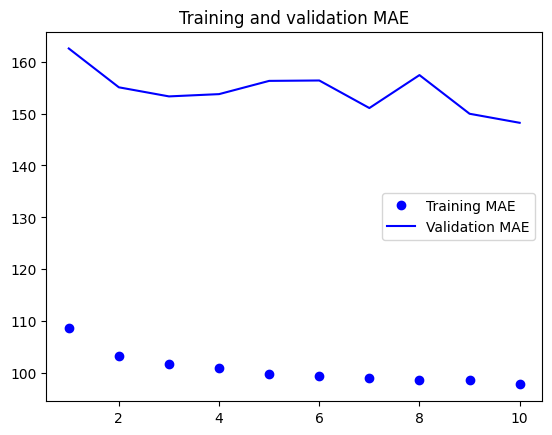

In [55]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

### Recurrent Network

In [59]:
num_features = 13
steps = 120
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 120, 13)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 120, 16)        │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 120, 16)        │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,536 (6.00 KB)

 Trainable params: 1,536 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

### LSTM

In [60]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("bike_sharing_ltsm.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("bike_sharing_ltsm.keras")
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - loss: 41779.7734 - mae: 152.2855 - val_loss: 97058.0547 - val_mae: 235.0789
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 41259.5664 - mae: 150.5296 - val_loss: 96526.4141 - val_mae: 233.8615
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 220ms/step - loss: 40780.6289 - mae: 149.0303 - val_loss: 95757.4297 - val_mae: 232.3875
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 40433.4688 - mae: 147.9744 - val_loss: 95425.3516 - val_mae: 231.6727
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 40178.0352 - mae: 147.2340 - val_loss: 94962.9453 - val_mae: 230.8206
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 39902.5469 - mae: 146.4203 - val_loss: 94614.8438 - val_mae: 230.1053
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 39587.4961 - mae: 145.6046 - val_loss: 94086.6406 - val_mae: 229.2115
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 39366.7930 - mae: 145.0431 - v

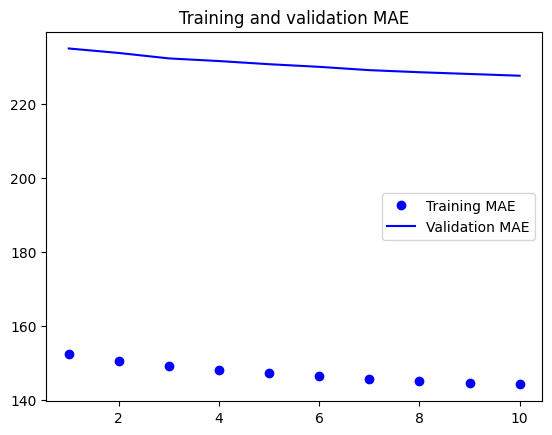

In [61]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

### LSTM com Dropout

In [62]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("bike_sharing_lstm_drop.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("bike_sharing_lstm_drop.keras")
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 41773.9805 - mae: 152.2744 - val_loss: 97372.1406 - val_mae: 235.7516
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 41546.6602 - mae: 151.5209 - val_loss: 97180.1562 - val_mae: 235.2570
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - loss: 41312.0078 - mae: 150.6873 - val_loss: 96597.0000 - val_mae: 234.0898
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 40991.8789 - mae: 149.6919 - val_loss: 96266.4453 - val_mae: 233.3154
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step - loss: 40727.8633 - mae: 148.8240 - val_loss: 95794.4062 - val_mae: 232.3011
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 40246.5156 - mae: 147.5049 - val_loss: 95090.4297 - val_mae: 231.1275
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - loss: 40061.1016 - mae: 146.9511 - val_loss: 94854.1641 - val_mae: 230.6386
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 39891.1211 - mae: 146.4058 - v

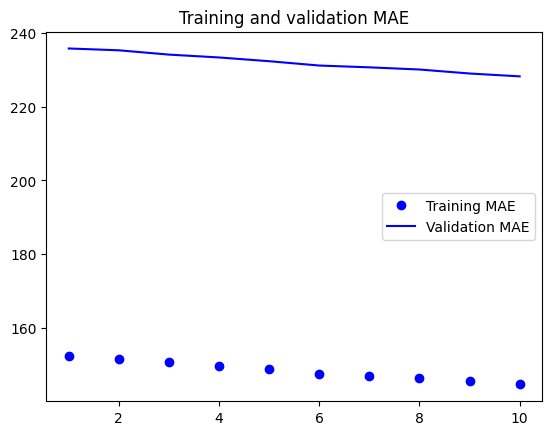

In [63]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

### Stacking recurrent layers

In [64]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("bike_sharing_stacked_gru.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("bike_sharing_stacked_gru.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 489ms/step - loss: 40647.1680 - mae: 148.8010 - val_loss: 94582.6016 - val_mae: 230.2127
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 350ms/step - loss: 39637.9023 - mae: 145.8300 - val_loss: 93931.3203 - val_mae: 229.0088
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 470ms/step - loss: 39279.4844 - mae: 144.8420 - val_loss: 93430.5078 - val_mae: 228.0999
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 390ms/step - loss: 38949.2305 - mae: 143.9513 - val_loss: 92946.5938 - val_mae: 227.2338
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 288ms/step - loss: 38658.9688 - mae: 143.1676 - val_loss: 92477.3984 - val_mae: 226.4050
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 307ms/step - loss: 38376.7852 - mae: 142.4445 - val_loss: 92003.3906 - val_mae: 225.5773
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 372ms/step - loss: 38068.8086 - mae: 141.6510 - val_loss: 91537.6484 - val_mae: 224.7706
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 333ms/step - loss: 37780.2461 - mae: 140.

### bidirectional LSTM

In [65]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("bike_sharing_bidirectional_lstm.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("bike_sharing_bidirectional_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - loss: 41643.1836 - mae: 151.8413 - val_loss: 97005.7500 - val_mae: 234.9144
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - loss: 41054.8984 - mae: 149.9236 - val_loss: 96157.5547 - val_mae: 233.1866
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - loss: 40589.2148 - mae: 148.4616 - val_loss: 95555.2109 - val_mae: 231.9452
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - loss: 40075.4727 - mae: 146.9395 - val_loss: 94652.4062 - val_mae: 230.2303
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - loss: 39382.3789 - mae: 145.0241 - val_loss: 93553.2812 - val_mae: 228.2822
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 38736.7891 - mae: 143.3438 - val_loss: 92526.3906 - val_mae: 226.4459
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - loss: 38249.6758 - mae: 142.0769 - val_loss: 91846.5938 - val_mae: 225.2786
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - loss: 37924.3438 - mae: 141.2538 - v

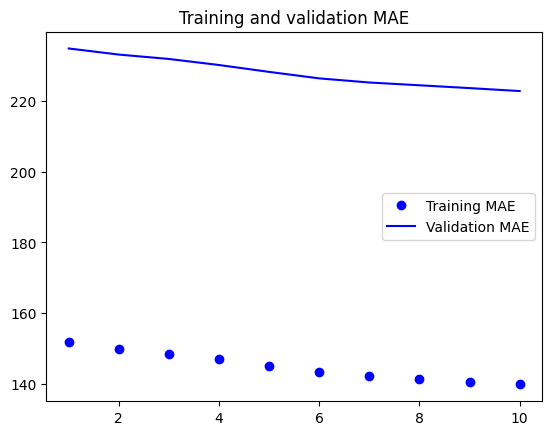

In [66]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

### Parâmetros utilizados

O sampling_rate = 1 indica que todas as observações horárias são utilizadas, sem pular registros. Como a base já está em granularidade horária, isso permite preservar a sequência completa da série temporal.

O sequence_length = 24 define que cada amostra de entrada terá uma janela com as últimas 24 horas de dados. Essa escolha é adequada porque a demanda por bicicletas tem forte padrão diário: horários de pico, madrugada, manhã, tarde e noite.

O delay = 1 indica que o modelo deve prever o valor da próxima hora. Assim, a entrada contém as últimas 24 horas e o alvo é o cnt uma hora à frente.

O batch_size = 32 define que o modelo processa 32 janelas por atualização dos pesos. Esse é um valor padrão e estável para treinamento com redes neurais, equilibrando custo computacional e estabilidade do gradiente.